In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate

In [2]:
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

path = '../../dataset/ptb_xl/'
sampling_rate=100

# load and convert annotation data
Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load raw signal data
X = load_raw_data(Y, sampling_rate, path)
# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

# Split data into train and test
test_fold = 10
# Train
X_train = X[np.where(Y.strat_fold != test_fold)]
y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
# Test
X_test = X[np.where(Y.strat_fold == test_fold)]
y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass

def minmax_normalize_signals(signals):
    # signals: (num_samples, num_timesteps, num_channels)
    min_val = signals.min(axis=(1,2), keepdims=True)
    max_val = signals.max(axis=(1,2), keepdims=True)
    return (signals - min_val) / (max_val - min_val + 1e-8)

# After loading X_train and X_test:
X_train = minmax_normalize_signals(X_train)
X_test = minmax_normalize_signals(X_test)


In [3]:
def plot_ecg_12_leads(data_plot, data_label=['NORM']):
    plt.figure(figsize=(24,12))
    print(f"Class {data_label}")
    ecg_leads = {
        0: "I",
        1: "II",
        2: "III",
        3: "aVR",
        4: "aVL",
        5: "aVF",
        6: "V1",
        7: "V2",
        8: "V3",
        9: "V4",
        10: "V5",
        11: "V6"
    }
    for i in range(12):
        plt.subplot(4,3,i+1)
        plt.plot(data_plot[:, i])
        plt.title(f"Lead {ecg_leads[i]}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.grid(True)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()

In [4]:
# print("Count number of classes of y_train")
# counts = y_train.value_counts().sort_index()  # Sort by class label (0 → 4)
# print(counts)

In [5]:
#print("Count number of classes of y_test")
#counts = y_test.value_counts().sort_index()  # Sort by class label (0 → 4)
#print(counts)

Class ['NORM']


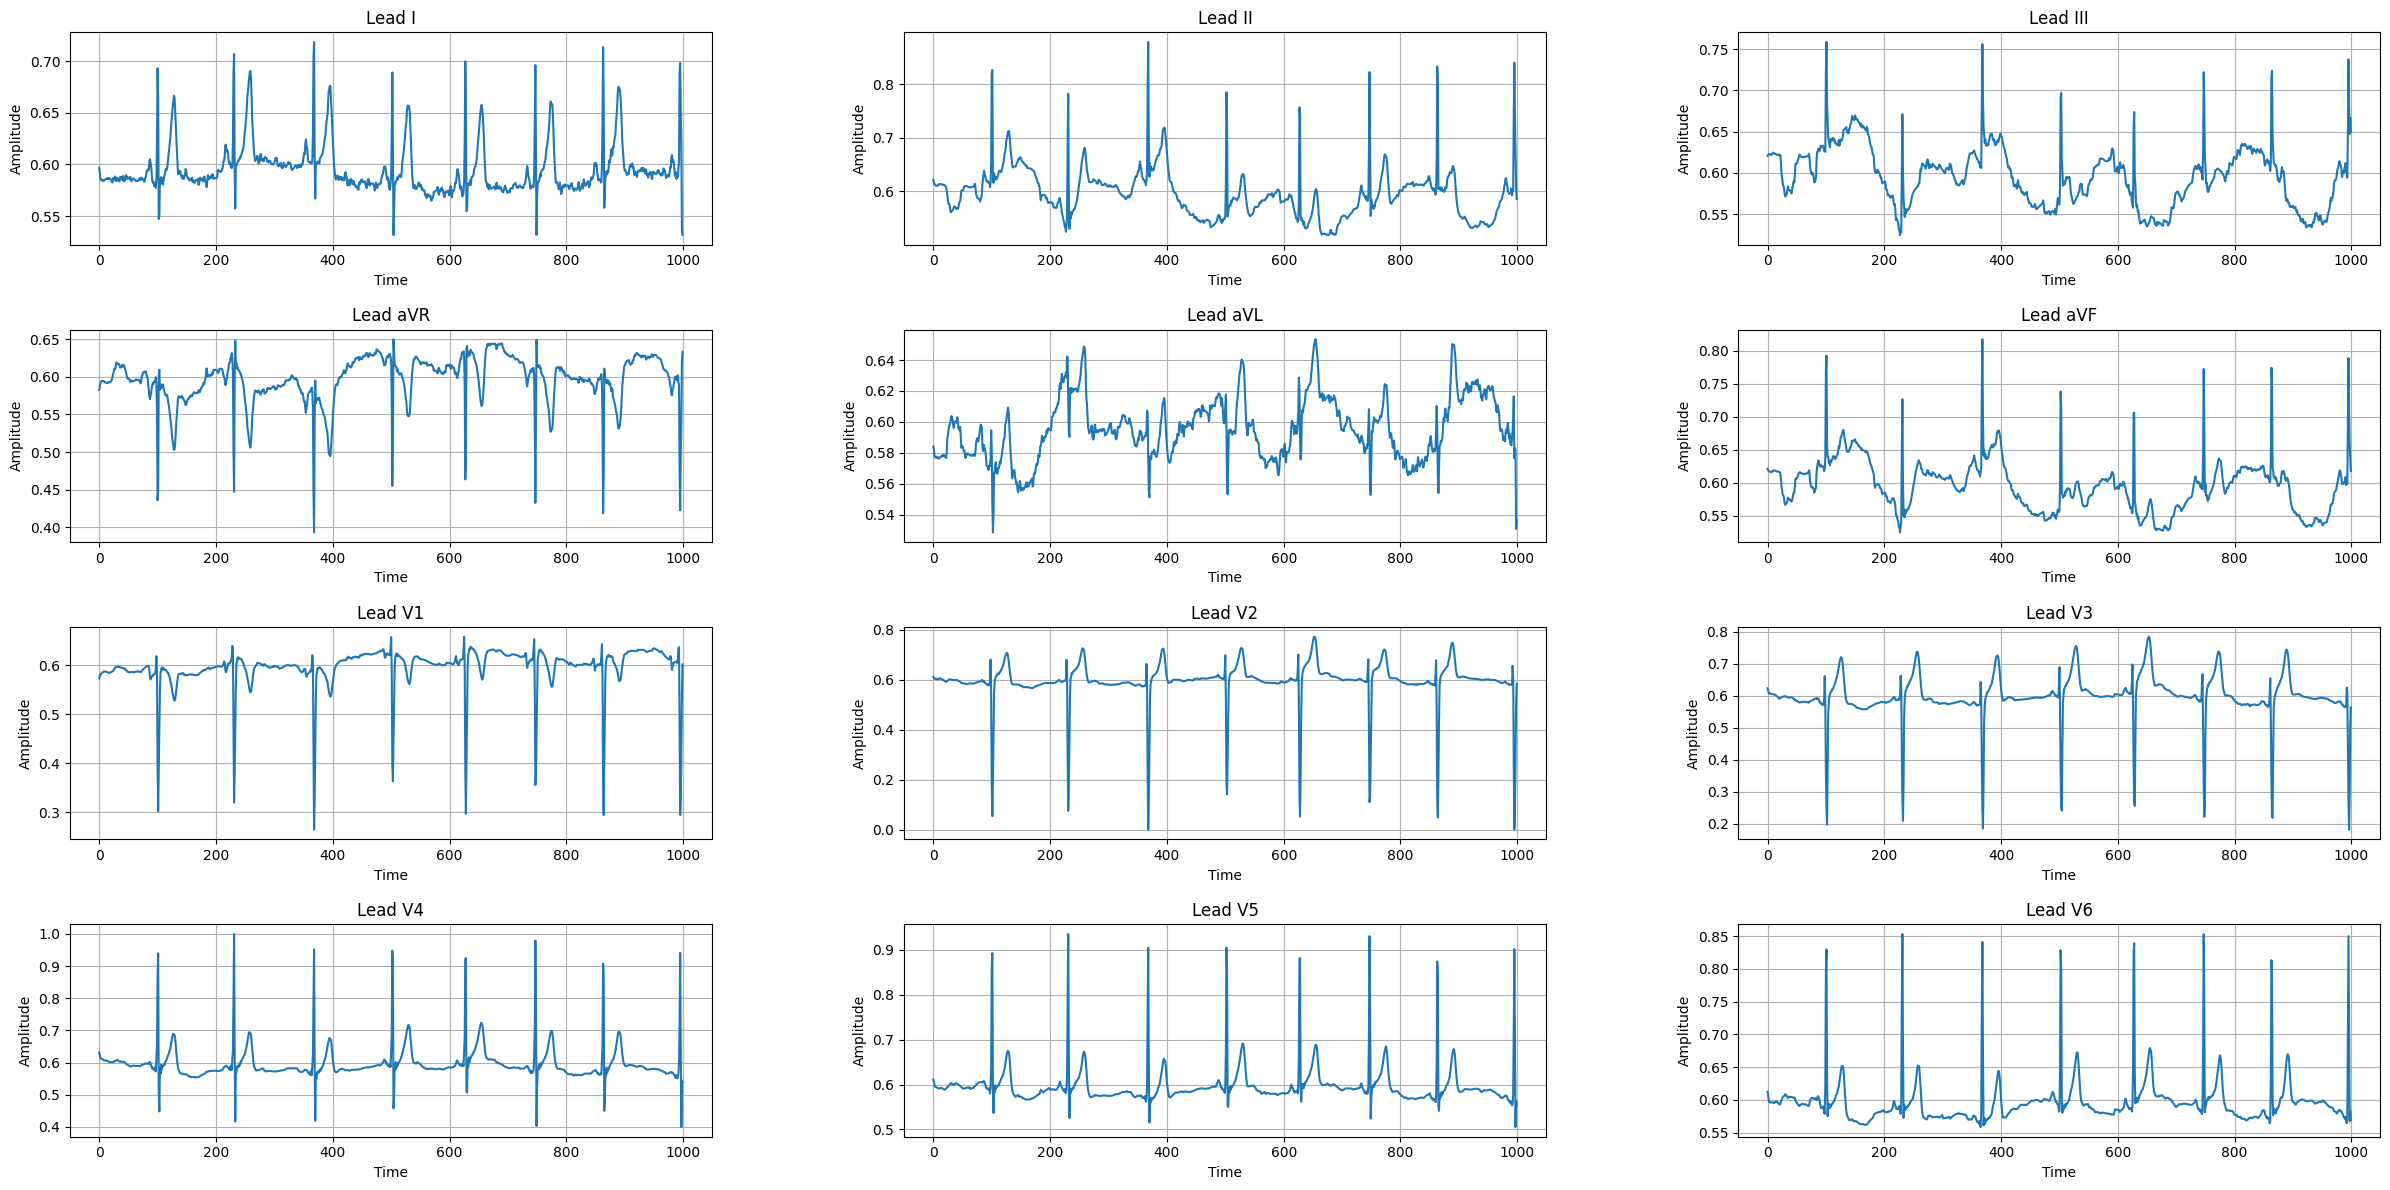

In [6]:
plot_ecg_12_leads(X_train[1, :], y_train[1])

In [7]:
# Define label mapping
label_map = {'NORM': 0, 'CD': 1, 'HYP': 2, 'MI': 3, 'STTC': 4}
# Convert and filter

def mapping_label_and_filter_signals_np(signals: np.ndarray, labels: list, label_map: dict = label_map):
    converted_labels = []
    valid_indices = []
    
    for i, lbl_list in enumerate(labels):
        if lbl_list:  # skip empty labels
            mapped = [label_map[label] for label in lbl_list if label in label_map]
            converted_labels.append(mapped)
            valid_indices.append(i)
    
    # Use valid indices to slice the numpy signals array
    filtered_signals = signals[valid_indices, :, :]
    
    return filtered_signals, converted_labels

In [8]:
X_train_, y_train_ = mapping_label_and_filter_signals_np(X_train, y_train)
y_train_ = pd.Series(y_train_)
#counts_train_label = y_train_.value_counts().sort_index()  # Sort by class label (0 → 4)
#print(counts_train_label)

In [9]:
X_test_, y_test_ = mapping_label_and_filter_signals_np(X_test, y_test)
y_test_ = pd.Series(y_test_)
#counts = y_test_.value_counts().sort_index()  # Sort by class label (0 → 4)
#print(counts)

In [10]:
def labels_to_multihot(label_list, num_classes=5):
    y = torch.zeros((len(label_list), num_classes))
    for i, labels in enumerate(label_list):
        y[i, labels] = 1
    return y

y_train_one_hot = labels_to_multihot(y_train_, num_classes=5)  # shape: (500, 5)
y_test_one_hot = labels_to_multihot(y_test_, num_classes=5)  # shape: (500, 5)

In [11]:
x_train = torch.from_numpy(X_train_).float()  # float tensor for input
train, val, labels_train, labels_val = train_test_split(
    x_train, y_train_one_hot, test_size=0.2, random_state=42, shuffle=True
)
x_test = torch.from_numpy(X_test_).float()

batch_size = 64

train_dataset = TensorDataset(train, labels_train)
val_dataset = TensorDataset(val, labels_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test = TensorDataset(x_test, y_test_one_hot)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

In [12]:
import torch
import torch.nn as nn

class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_sizes=[3,3], pooling_kernel=4):
        super().__init__()
        layers = []
        for i, k in enumerate(kernel_sizes):
            layers.append(nn.Conv1d(in_channels if i == 0 else out_channels, out_channels, kernel_size=k, padding=k//2))
            layers.append(nn.BatchNorm1d(out_channels))
            layers.append(nn.LeakyReLU(0.01))
        layers.append(nn.MaxPool1d(pooling_kernel))
        self.block = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.block(x)

class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding)
        self.relu = nn.LeakyReLU(0.01)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, padding=padding)
        # If in_channels != out_channels, use a 1x1 conv to match dimensions
        self.shortcut = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size//2) if in_channels != out_channels else nn.Identity()
        self.batchnorm = nn.BatchNorm1d(out_channels * 2)
    def forward(self, x):
        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)
        # Concatenate along the channel dimension (dim=1)
        shortcut = self.shortcut(x)
        out = torch.cat([out, shortcut], dim=1)
        out = self.batchnorm(out)
        out = self.relu(out)
        return out

class MultiStageCNNGRU(nn.Module):
    def __init__(self, in_channels=12, num_classes=5, gru_hidden_size=64, gru_layers=1):
        super().__init__()
        
        # First CNN block
        self.cnn_block1 = CNNBlock(in_channels, 32, kernel_sizes=[5,3])
        
        # First GRU layer
        self.gru1 = nn.GRU(input_size=32, hidden_size=gru_hidden_size, num_layers=gru_layers,
                           batch_first=False, bidirectional=True)
        
        self.rcnn_block1 = ResNetBlock(gru_hidden_size*2, 32, kernel_size=3, padding=1)  # Residual block
        
        # Second CNN block
        self.cnn_block2 = CNNBlock(32*2, 64, kernel_sizes=[5,5])
        

        # Second GRU layer
        self.gru2 = nn.GRU(input_size=64, hidden_size=gru_hidden_size, num_layers=gru_layers,
                           batch_first=False, bidirectional=True)
        
        # Third CNN block
        self.cnn_block3 = CNNBlock(gru_hidden_size * 2, 64, kernel_sizes=[5,3])
        
        self.rcnn_block2 = ResNetBlock(64, 32, kernel_size=3, padding=1)  # Residual block
        
        # Fully connected head
        self.fc_layers = nn.Sequential(
            nn.AdaptiveAvgPool1d(2),  # output shape (batch, 64, 16)
            nn.Flatten(),             # (batch, 256)
            nn.Linear(2 * 32 * 2, 128),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        # x: (batch, channels, seq_len)
        x = self.cnn_block1(x)  # (batch, 32, L)
        x = x.permute(2, 0, 1)  # (L, batch, 32)
        x, _ = self.gru1(x)     # (L, batch, hidden*2)
        x = x.permute(1, 2, 0)  # (batch, hidden*2, L)
        
        x = self.rcnn_block1(x)  # (batch, 32*2, L)
        
        x = self.cnn_block2(x)  # (batch, 64, L2)
        x = x.permute(2, 0, 1)  # (L2, batch, 64)
        x, _ = self.gru2(x)     # (L2, batch, hidden*2)
        x = x.permute(1, 2, 0)  # (batch, hidden*2, L2)
        
        x = self.cnn_block3(x)  # (batch, 128, L3)
        
        x = self.rcnn_block2(x)  # (batch, 32*2, L)
        
        out = self.fc_layers(x)  # (batch, num_classes)
        return out

# ...existing code...

# To use the GRU model, instantiate it like this:
# model = MultiStageCNNGRU().to(device)


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MultiStageCNNGRU().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

In [14]:
# 4. Training loop
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs.transpose(1, 2))  # CNN expects (batch, channels, seq_len)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs.transpose(1, 2))
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)

    val_loss /= len(val_loader.dataset)
    # Print with color and progress bar
    epoch_str = f"\033[1;36mEpoch {epoch+1}/{num_epochs}\033[0m"
    bar_len = 30
    filled_len = int(round(bar_len * (epoch+1) / float(num_epochs)))
    bar = '=' * filled_len + '-' * (bar_len - filled_len)
    print(f"{epoch_str} [{bar}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


model.eval()
test_loss = 0.0
criterion = nn.BCEWithLogitsLoss()  # or your chosen loss

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs.transpose(1, 2))
        loss = criterion(outputs, targets)
        test_loss += loss.item() * inputs.size(0)

test_loss /= len(test_loader.dataset)
print(f"Test Loss: {test_loss:.4f}")

Epoch 1/50 [=-----------------------------] | Train Loss: 0.4471 | Val Loss: 0.6308
Epoch 2/50 [=-----------------------------] | Train Loss: 0.3753 | Val Loss: 0.4006
Epoch 3/50 [==----------------------------] | Train Loss: 0.3547 | Val Loss: 0.3883
Epoch 4/50 [==----------------------------] | Train Loss: 0.3347 | Val Loss: 0.3555
Epoch 5/50 [===---------------------------] | Train Loss: 0.3256 | Val Loss: 0.3467
Epoch 6/50 [====--------------------------] | Train Loss: 0.3201 | Val Loss: 0.3354
Epoch 7/50 [====--------------------------] | Train Loss: 0.3117 | Val Loss: 0.3312
Epoch 8/50 [=====-------------------------] | Train Loss: 0.3048 | Val Loss: 0.3643
Epoch 9/50 [=====-------------------------] | Train Loss: 0.2998 | Val Loss: 0.3147
Epoch 10/50 [======------------------------] | Train Loss: 0.2953 | Val Loss: 0.3212
Epoch 11/50 [=======-----------------------] | Train Loss: 0.2916 | Val Loss: 0.3086
Epoch 12/50 [=======-----------------------] | Train Loss: 0.2890 | Val Lo

In [15]:
def performance_evaluation(model=model, dataset = test_loader, dataset_name = "Test Set"):
    
    all_targets = []
    all_preds = []

    model.eval()
    with torch.no_grad():
        for inputs, targets in dataset:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs.transpose(1, 2))
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)

    num_classes = all_targets.shape[1]

    # Prepare table data
    table_data = []
    headers = ["Class", "Precision", "Recall (Sensitivity)", "Specificity", "TN", "FP", "FN", "TP"]

    for i in range(num_classes):
        y_true = all_targets[:, i]
        y_pred = all_preds[:, i]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            TN, FP, FN, TP = cm.ravel()
            total = TN + FP + FN + TP
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0

            # Format with percentage
            TN_str = f"{TN} ({TN/total*100:.1f}%)"
            FP_str = f"{FP} ({FP/total*100:.1f}%)"
            FN_str = f"{FN} ({FN/total*100:.1f}%)"
            TP_str = f"{TP} ({TP/total*100:.1f}%)"
        else:
            TN_str = FP_str = FN_str = TP_str = "0 (0.0%)"
            specificity = 0.0

        table_data.append([
            i,
            f"{precision:.4f}",
            f"{recall:.4f}",
            f"{specificity:.4f}",
            TN_str,
            FP_str,
            FN_str,
            TP_str,
        ])
    print(f"\n------------Performance Evaluation Metrics per Class({dataset_name}) -----------\n")
    print(tabulate(table_data, headers=headers, tablefmt="grid"))
    return all_targets, all_preds

In [16]:
targets_train, preds_train = performance_evaluation(model, train_loader, "Train Set")
targets_val, preds_val = performance_evaluation(model, val_loader, "Val Set")
targets_test, preds_test = performance_evaluation(model, test_loader, "Test Set")


------------Performance Evaluation Metrics per Class(Train Set) -----------

+---------+-------------+------------------------+---------------+---------------+-------------+------------+--------------+
|   Class |   Precision |   Recall (Sensitivity) |   Specificity | TN            | FP          | FN         | TP           |
+=========+=============+========================+===============+===============+=============+============+==============+
|       0 |      0.9617 |                 0.8575 |        0.9728 | 8335 (54.2%)  | 233 (1.5%)  | 971 (6.3%) | 5845 (38.0%) |
+---------+-------------+------------------------+---------------+---------------+-------------+------------+--------------+
|       1 |      0.9027 |                 0.7822 |        0.9752 | 11590 (75.3%) | 295 (1.9%)  | 762 (5.0%) | 2737 (17.8%) |
+---------+-------------+------------------------+---------------+---------------+-------------+------------+--------------+
|       2 |      0.6402 |                 0.639

In [17]:
def plot_confusion_matrix_per_class_multi(y_true_list, y_pred_list, class_names=None, set_names=None):
    """
    Plot confusion matrices for multiple sets (e.g., test, val, train) in columns.
    y_true_list, y_pred_list: list of arrays, each for a set.
    set_names: list of names for each set.
    """
    metric_label = ["TN", "FP", "FN", "TP"]
    num_sets = len(y_true_list)
    num_classes = y_true_list[0].shape[1]
    if set_names is None:
        set_names = [f"Set {i+1}" for i in range(num_sets)]
    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]

    for class_idx in range(num_classes):
        fig, axes = plt.subplots(1, num_sets, figsize=(5*num_sets, 4))
        if num_sets == 1:
            axes = [axes]
        for set_idx in range(num_sets):
            y_true = y_true_list[set_idx][:, class_idx]
            y_pred = y_pred_list[set_idx][:, class_idx]
            cm = confusion_matrix(y_true, y_pred)
            total = np.sum(cm)
            if cm.size == 4:
                annot = np.empty_like(cm).astype(str)
                for r in range(2):
                    for c in range(2):
                        count = cm[r, c]
                        row_sum = np.sum(cm[r, :])
                        row_percent = 100 * count / row_sum if row_sum > 0 else 0
                        annot[r, c] = f"{count}\n({metric_label[r*2+c]}:{row_percent:.1f}%)"
            else:
                annot = cm
            sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
                        xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'],
                        ax=axes[set_idx])
            axes[set_idx].set_title(f"{set_names[set_idx]}")
            axes[set_idx].set_xlabel('Predicted label')
            axes[set_idx].set_ylabel('True label')
        plt.suptitle(f'Confusion Matrix - {class_names[class_idx]}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()



confusion_matrix (Test Set)


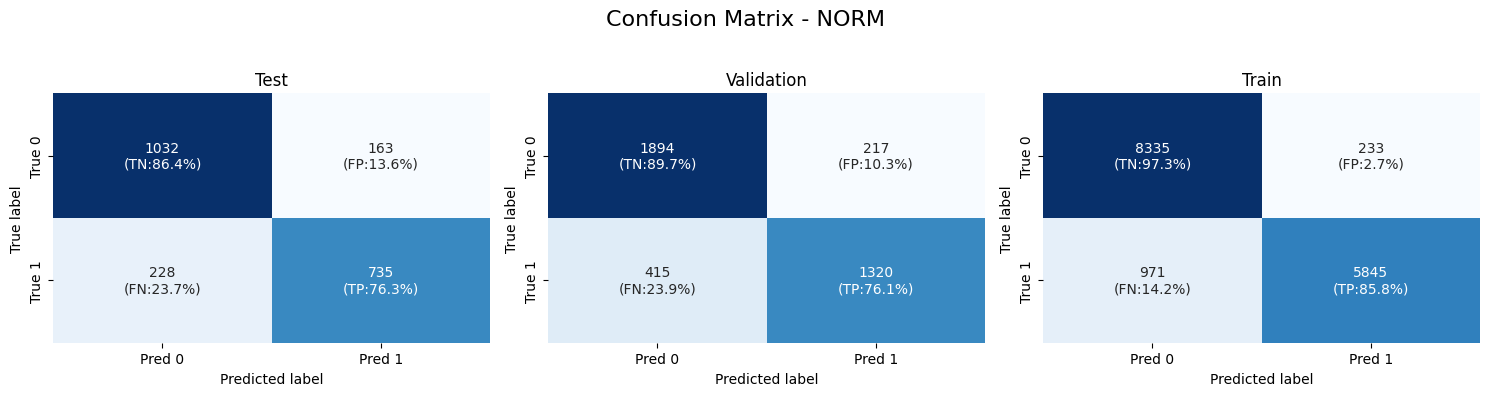

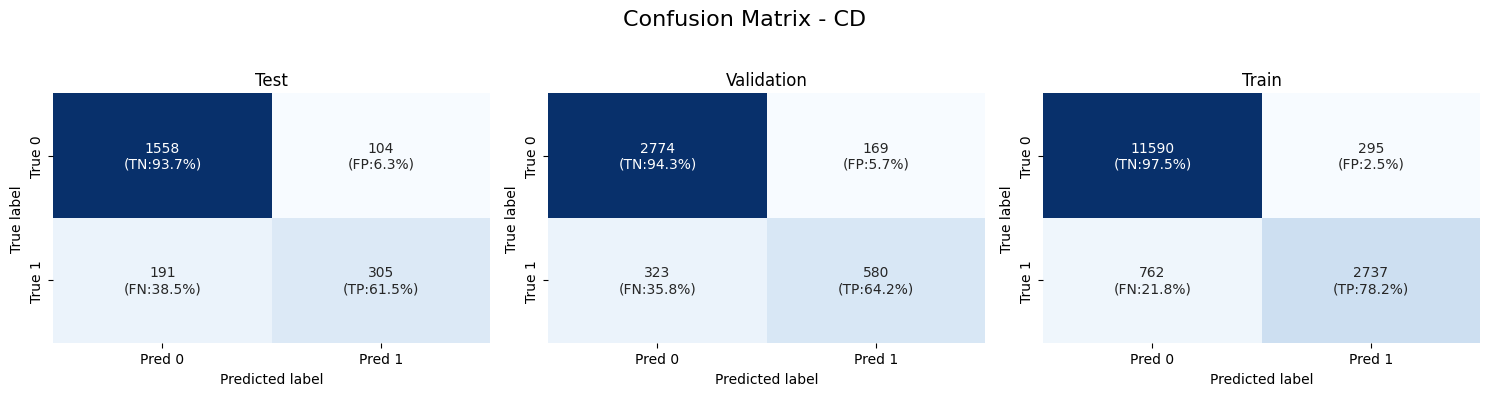

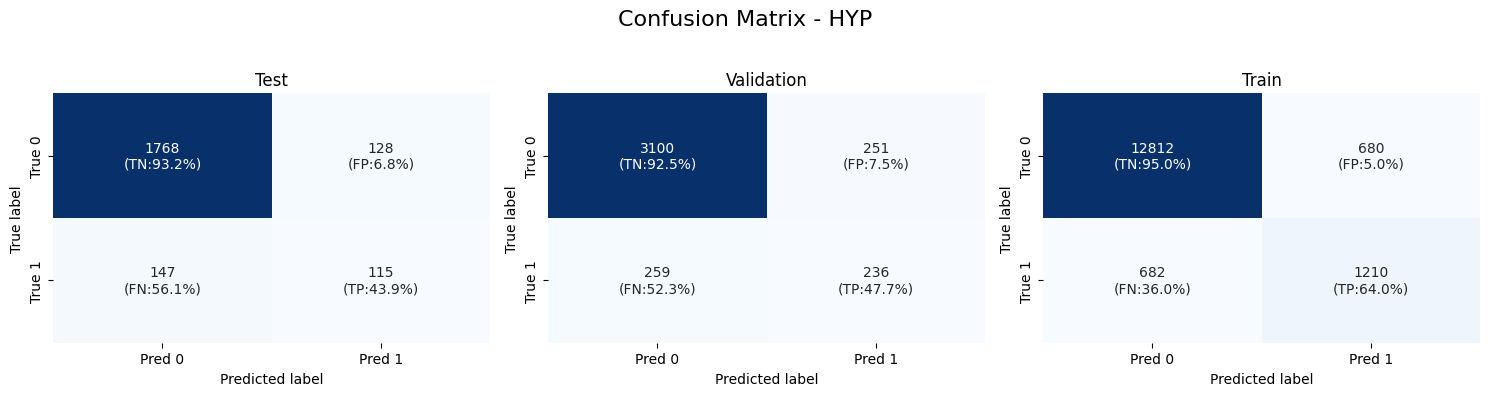

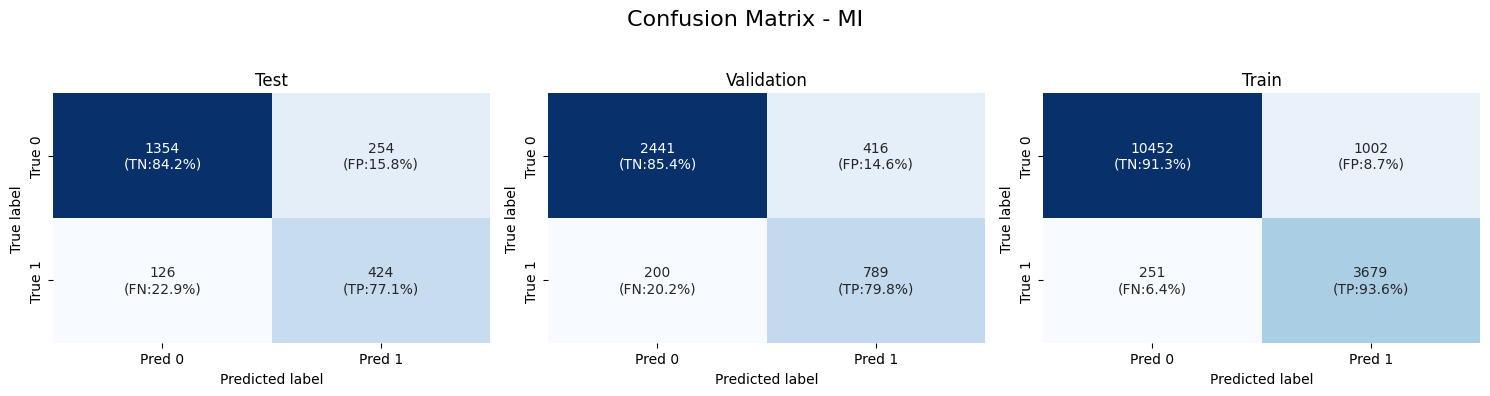

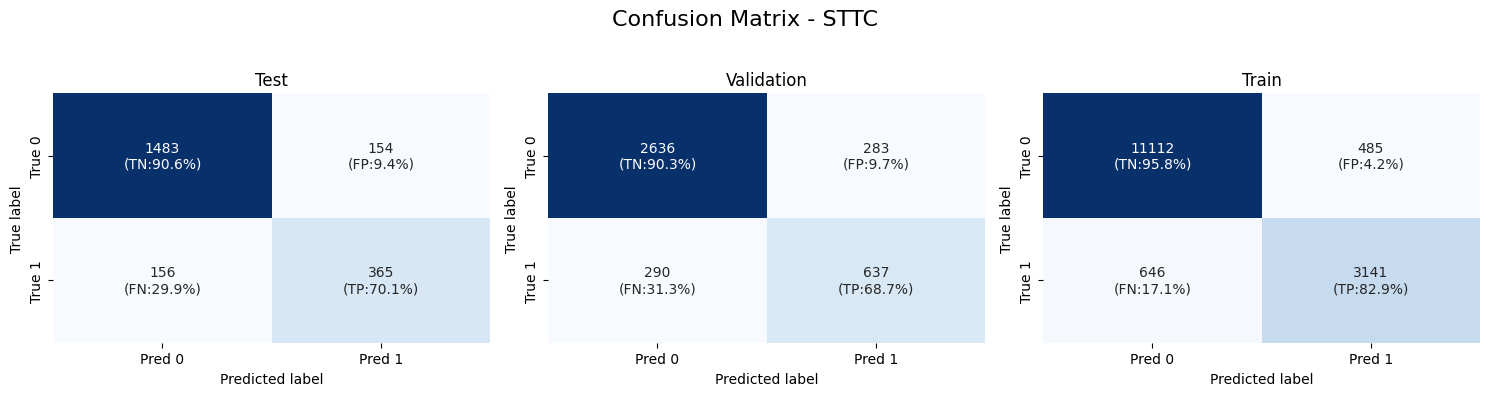

In [18]:
classes_name = {'NORM': 0, 'CD': 1, 'HYP': 2, 'MI': 3, 'STTC': 4}
print("confusion_matrix (Test Set)")
#plot_confusion_matrix_per_class(targets_test, preds_test, list(classes_name.keys()))
set_names = ["Test", "Validation", "Train"]
plot_confusion_matrix_per_class_multi(
    [targets_test, targets_val, targets_train],
    [preds_test, preds_val, preds_train],
    class_names=list(classes_name.keys()),
    set_names=set_names
)

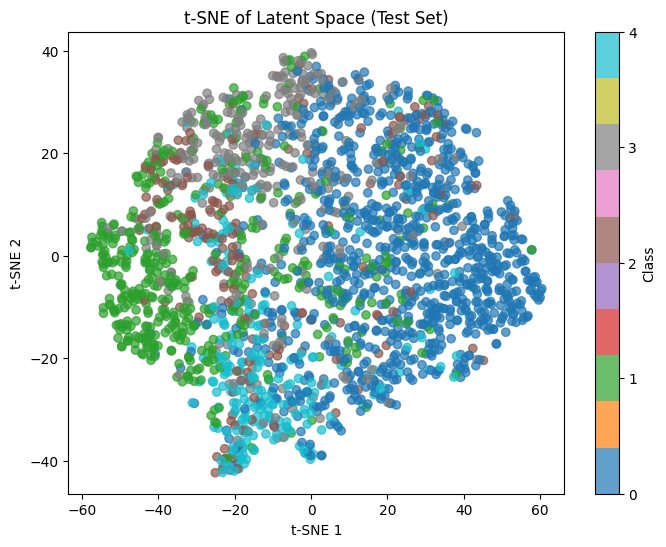

In [ ]:
from sklearn.manifold import TSNE

        
def extract_latent_features(model, data_loader, device):
    model.eval()
    features = []
    labels = []
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device)
            # Forward up to the penultimate layer
            x = model.cnn_block1(inputs.transpose(1, 2))
            x = x.permute(2, 0, 1)
            x, _ = model.gru1(x)
            x = x.permute(1, 2, 0)
            x = model.rcnn_block1(x)
            x = model.cnn_block2(x)
            x = x.permute(2, 0, 1)
            x, _ = model.gru2(x)
            x = x.permute(1, 2, 0)
            x = model.cnn_block3(x)
            x = model.rcnn_block2(x)
            # Extract features before the final classifier
            x = model.fc_layers[0](x)  # AdaptiveMaxPool1d
            x = model.fc_layers[1](x)  # Flatten
            features.append(x.cpu().numpy())
            labels.append(targets.cpu().numpy())
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    return features, labels

# Extract features and labels from test set
latent_features, latent_labels = extract_latent_features(model, test_loader, device)

# For multi-label, use argmax or sum to get a single class per sample for visualization
label_ids = np.argmax(latent_labels, axis=1)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_2d = tsne.fit_transform(latent_features)

# Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(latent_2d[:,0], latent_2d[:,1], c=label_ids, cmap='tab10', alpha=0.7)
plt.title("t-SNE of Latent Space (Test Set)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, ticks=range(latent_labels.shape[1]), label='Class')
plt.show()